# LLM Inference Acceleration

> How long do you wait for a 500-token response? Under a naive implementation, every new token reprocesses all previous tokens -- the longer the sequence, the more repeated work accumulates, to the point of being unusable.
>
> This section breaks down the root cause of slow inference and implements several core acceleration techniques from scratch: KV Cache to avoid recomputing historical states, MQA/GQA to shrink the cache, quantization to compress weights and caches, and FlashAttention to make Attention hardware-friendly. Finally, we use llama-cpp-python to load a real GGUF model and experience the results.

LLM inference has two phases: prefill (processes the entire input prompt at once, can be parallelized) and decode (generates tokens one by one, inherently sequential).

The decode phase is often memory-bandwidth-bound: each generated token reads model weights, and the amount of KV Cache read grows with context length.

Understanding this bottleneck reveals where each acceleration technique targets: KV Cache avoids recomputing prior tokens' K/V and hidden states, MQA/GQA reduces the K/V that each token must store, quantization reduces the amount of data per read, and FlashAttention reduces intermediate GPU memory traffic.

In [1]:
import torch
import numpy as np

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 1. Why Generation Is Slow

Recall the autoregressive generation process:

```
Step 1: Input [BOS]              -> compute attention -> predict "I"
Step 2: Input [BOS, I]           -> compute attention -> predict "love"
Step 3: Input [BOS, I, love]     -> compute attention -> predict "you"
Step 4: Input [BOS, I, love, you]-> compute attention -> predict EOS
```

Step 2 recomputes the K, V, and hidden states that Step 1 already computed. Step 3 recomputes Steps 1+2. Below, `1+2+3+...+N = O(N^2)` is a rough proxy for the amount of repeated prefix processing, to see how fast the waste grows. Strictly speaking, KV Cache does not make all attention work O(N): during decode, the new token still attends to historical KV; it only avoids recomputing the previous tokens' states over and over.

In [2]:
def naive_generation_cost(n_tokens):
    return sum(range(1, n_tokens + 1))

print(f"{\'Length\':>8}  {\'Prefix-work proxy\':>18}  {\'Avoidable\':>10}  {\'Avoidable %\':>11}")
print("-" * 54)
for n in [10, 50, 100, 500, 1000, 2000]:
    cost = naive_generation_cost(n)
    wasted = cost - n
    ratio = wasted / cost * 100
    print(f"{n:>8d}  {cost:>18d}  {wasted:>10d}  {ratio:>10.1f}%")

print()
print("Generating 1000 tokens: under this proxy, 99.8% is repeated prefix processing.")
print("KV Cache removes this historical-state recomputation; the remaining decode work is often bandwidth-bound.")


Read the values printed above and connect them to the concept in this cell.------------------------------------------------
      10            55          45     81.8%
      50          1275        1225     96.1%
     100          5050        4950     98.0%
     500        125250      124750     99.6%
    1000        500500      499500     99.8%
    2000       2001000     1999000     99.9%

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.

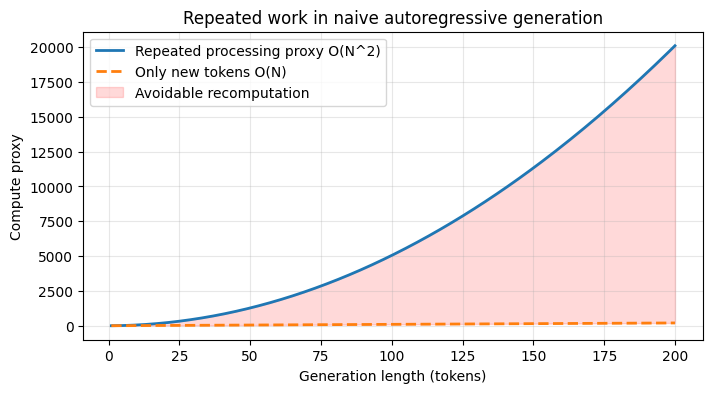

In [3]:
import matplotlib.pyplot as plt

lengths = list(range(1, 201))
naive_costs = [naive_generation_cost(n) for n in lengths]
optimal_costs = lengths

plt.figure(figsize=(8, 4))
plt.plot(lengths, naive_costs, label="Repeated prefix processing O(N^2)", linewidth=2)
plt.plot(lengths, optimal_costs, label="New-token work O(N)", linewidth=2, linestyle="--")
plt.fill_between(lengths, optimal_costs, naive_costs, alpha=0.15, color="red", label="Avoidable historical recomputation")
plt.xlabel("Generation length (tokens)")
plt.ylabel("Proxy work")
plt.title("Repeated prefix processing in naive autoregressive generation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("The red region is historical K/V and hidden-state recomputation that KV Cache can eliminate.")


## 2. KV Cache

Core idea: the K and V for previous tokens have already been computed -- store them and reuse them, don't recompute.

```
Step 1: Compute K1, V1 -> store in cache
Step 2: Only compute K2, V2 -> retrieve K1, V1 from cache -> concatenate for attention
Step 3: Only compute K3, V3 -> retrieve K1, V1, K2, V2 from cache -> concatenate for attention
```

Effect: when generating N tokens, previous tokens' K/V and hidden states are no longer recomputed at every step; that repeated prefix processing changes from triangular growth to doing new-token work each step. Attention still reads and uses historical KV, so long contexts shift pressure toward memory capacity and bandwidth. Let's first implement an Attention layer with KV Cache, then verify output equivalence, and finally do a timing comparison.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)
np.random.seed(42)

class AttentionWithKVCache(nn.Module):
    # Self-Attention with KV Cache
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.k_cache = None
        self.v_cache = None

    def reset_cache(self):
        self.k_cache = None
        self.v_cache = None

    def forward(self, x, use_cache=True):
        batch_size, seq_len, _ = x.shape
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        if use_cache:
            if self.k_cache is not None:
                K = torch.cat([self.k_cache, K], dim=2)
                V = torch.cat([self.v_cache, V], dim=2)
            self.k_cache = K
            self.v_cache = V

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        attn_output = weights @ V
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)

# Verify: output with cache should be identical to output without cache
attn = AttentionWithKVCache(d_model=32, num_heads=4)
x_full = torch.randn(1, 5, 32)

# Method 1: compute all at once
attn.reset_cache()
out_no_cache = attn(x_full, use_cache=False)

# Method 2: add tokens one by one
attn.reset_cache()
out1 = attn(x_full[:, :1, :], use_cache=True)
print(f"Step 1: input {list(x_full[:, :1, :].shape)} -> K cache {list(attn.k_cache.shape)}")

out_steps = [out1]
for i in range(1, 5):
    x_new = x_full[:, i:i+1, :]
    out_i = attn(x_new, use_cache=True)
    out_steps.append(out_i)
    print(f"Step {i+1}: input {list(x_new.shape)} -> K cache {list(attn.k_cache.shape)}")

out_with_cache = torch.cat(out_steps, dim=1)
diff = (out_no_cache - out_with_cache).abs().max().item()
print(f"\nOutput without cache: {list(out_no_cache.shape)}")
print(f"Output with cache: {list(out_with_cache.shape)}")
print(f"Max difference: {diff:.2e} <- within floating-point precision, results are equivalent")


Step 1: Input [1, 1, 32] → K cache [1, 4, 1, 8]Step 2: Input [1, 1, 32] → K cache [1, 4, 2, 8]Step 3: Input [1, 1, 32] → K cache [1, 4, 3, 8]Step 4: Input [1, 1, 32] → K cache [1, 4, 4, 8]Step 5: Input [1, 1, 32] → K cache [1, 4, 5, 8]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**KV Cache shape evolution**

Observe the cache shapes above:

```
Step 1: K cache = [1, 4, 1, 8]   <- only 1 token
Step 2: K cache = [1, 4, 2, 8]   <- appended 2nd token
...
Step 5: K cache = [1, 4, 5, 8]   <- all 5 tokens
```

Shape meaning: `[batch, num_heads, cached_seq_len, d_k]`. Each step only computes K and V for 1 new token; the rest are retrieved from cache.

In [5]:
import torch
import time

attn_bench = AttentionWithKVCache(d_model=256, num_heads=8)
SEQ_LEN = 50

torch.manual_seed(42)
full_seq = torch.randn(1, SEQ_LEN, 256)
start = time.perf_counter()
for step in range(SEQ_LEN):
    _ = attn_bench(full_seq[:, :step+1, :], use_cache=False)
no_cache_time = time.perf_counter() - start

attn_bench.reset_cache()
torch.manual_seed(42)
full_seq = torch.randn(1, SEQ_LEN, 256)
start = time.perf_counter()
_ = attn_bench(full_seq[:, :1, :], use_cache=True)
for step in range(1, SEQ_LEN):
    _ = attn_bench(full_seq[:, step:step+1, :], use_cache=True)
cache_time = time.perf_counter() - start

print(f"Sequence length: {SEQ_LEN}")
print(f"Without KV Cache: {no_cache_time*1000:.1f} ms")
print(f"With KV Cache: {cache_time*1000:.1f} ms")
print(f"Speedup: {no_cache_time/cache_time:.1f}x")
print()
print("Note: the gap is limited on CPU. On GPU, the difference for long sequences (>1000 tokens) is much larger.")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.

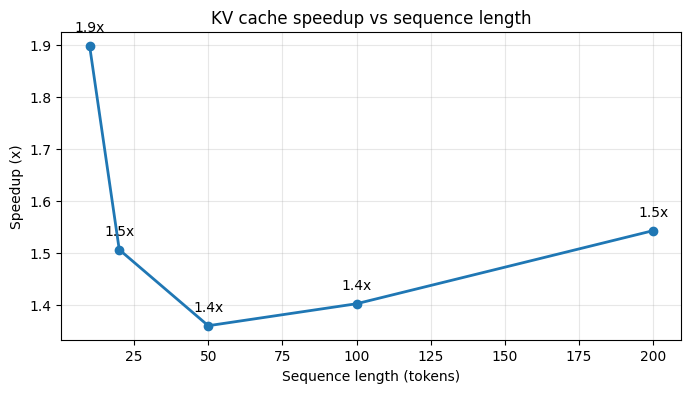

In [6]:
import torch
import matplotlib.pyplot as plt
import time

lengths_to_test = [10, 20, 50, 100, 200]
speedups = []

for seq_len in lengths_to_test:
    attn_test = AttentionWithKVCache(d_model=256, num_heads=8)
    test_seq = torch.randn(1, seq_len, 256)
    start = time.perf_counter()
    for step in range(seq_len):
        _ = attn_test(test_seq[:, :step+1, :], use_cache=False)
    t_no = time.perf_counter() - start

    attn_test.reset_cache()
    start = time.perf_counter()
    _ = attn_test(test_seq[:, :1, :], use_cache=True)
    for step in range(1, seq_len):
        _ = attn_test(test_seq[:, step:step+1, :], use_cache=True)
    t_yes = time.perf_counter() - start
    speedups.append(t_no / t_yes)

plt.figure(figsize=(8, 4))
plt.plot(lengths_to_test, speedups, marker="o", linewidth=2)
plt.xlabel("Sequence length (tokens)")
plt.ylabel("Speedup (x)")
plt.title("KV Cache speedup vs sequence length")
plt.grid(True, alpha=0.3)
for x, y in zip(lengths_to_test, speedups):
    plt.annotate(f"{y:.1f}x", (x, y), textcoords="offset points", xytext=(0, 10), ha="center")
plt.show()
print("The longer the sequence, the greater the KV Cache advantage.")


## 3. KV Cache Memory Overhead

KV Cache solves the computation problem but introduces a memory problem. The KV Cache size per token:

```
KV Cache per token = 2(K+V) x num_layers x d_model x bytes_per_value
```

Let's calculate with real model numbers.

In [7]:
def kv_cache_size(num_layers, num_heads, head_dim, seq_len, bpv=2):
    return 2 * num_layers * num_heads * head_dim * seq_len * bpv

def fmt_size(b):
    if b >= 1024**3: return f"{b/1024**3:.1f} GB"
    return f"{b/1024**2:.0f} MB"

models = {
    "LLaMA-2 7B":  (32, 32, 128),
    "LLaMA-2 13B": (40, 40, 128),
    "LLaMA-2 70B": (80, 64, 128),
}
ctx_lengths = [2048, 8192, 32768, 131072]
ctx_labels = ["2K", "8K", "32K", "128K"]
precisions = {"FP16": 2, "INT8": 1, "INT4": 0.5}

for mname, (nl, nh, hd) in models.items():
    print(f"=== {mname} ({nl} layers, {nh} heads, {hd} dim/head) ===")
    header = f"{\'Context\':<8}" + "".join(f"{p:>10}" for p in precisions)
    print(header)
    print("-" * 38)
    for i, sl in enumerate(ctx_lengths):
        row = f"{ctx_labels[i]:<8}"
        for prec, bpv in precisions.items():
            row += f"{fmt_size(kv_cache_size(nl, nh, hd, sl, bpv)):>10}"
        print(row)
    fp16_32k = kv_cache_size(nl, nh, hd, 32768, 2)
    users = 80 * 1024**3 // fp16_32k if fp16_32k > 0 else 0
    print(f"  -> 32K context, FP16, 80GB VRAM: supports ~{users} concurrent users\n")

print("70B model with 128K context requires 80+ GB of KV Cache. Quantizing to INT4 saves 75%.")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.--------------------------------------
2K          1.0 GB    512 MB    256 MB
8K          4.0 GB    2.0 GB    1.0 GB
32K        16.0 GB    8.0 GB    4.0 GB
128K       64.0 GB   32.0 GB   16.0 GB
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.--------------------------------------
2K          1.6 GB    800 MB    400 MB
8K          6.2 GB    3.1 GB    1.6 GB
32K        25.0 GB   12.5 GB    6.2 GB
128K      100.0 GB   50.0 GB   25.0 GB
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.--------

Read the values printed above and connect them to the concept in this cell.

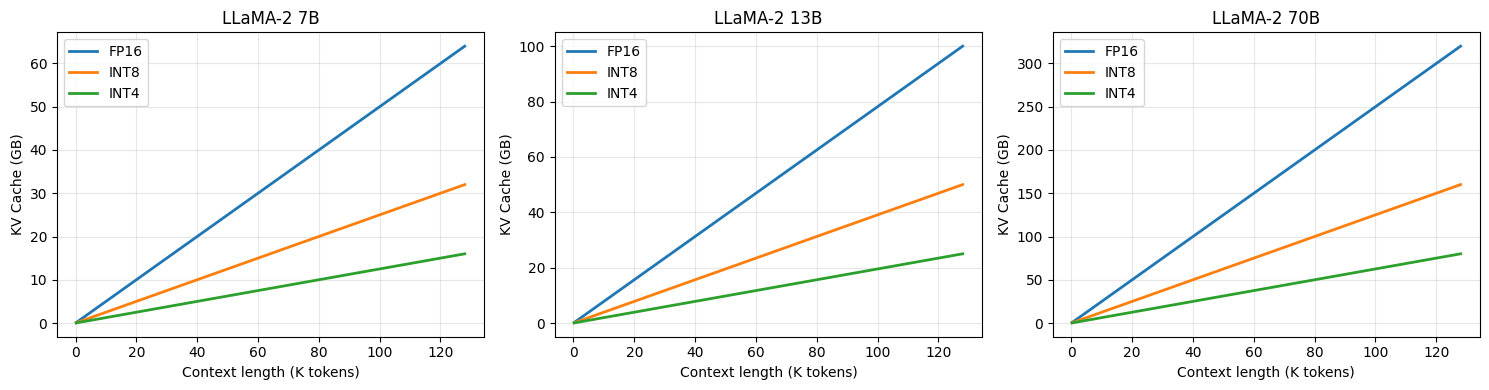

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (mname, (nl, nh, hd)) in enumerate(models.items()):
    ax = axes[idx]
    seq_range = np.linspace(256, 131072, 200)
    for prec, bpv in precisions.items():
        sizes = [kv_cache_size(nl, nh, hd, int(s), bpv) / 1024**3 for s in seq_range]
        ax.plot(seq_range / 1024, sizes, label=prec, linewidth=2)
    ax.set_xlabel("Context length (K tokens)")
    ax.set_ylabel("KV Cache (GB)")
    ax.set_title(mname)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The longer the sequence and the larger the model, the more severe the KV Cache memory pressure.")


## 4. MHA, MQA, GQA: Storing Less K/V

You just saw that KV Cache saves computation but eats memory. Is there a way to make the cache itself smaller?

First, three terms:

- **MHA (Multi-Head Attention)**: each Query head has its own set of Key/Value heads.
- **MQA (Multi-Query Attention)**: multiple Query heads share a single set of Key/Value heads.
- **GQA (Grouped-Query Attention)**: Query heads are grouped, with each group sharing one set of Key/Value heads.

Intuitively, you can think of Query heads as "people asking questions" and Key/Value heads as "filing cabinets".

MHA gives everyone their own filing cabinet: the most complete data, but the most cabinets. MQA has everyone share one cabinet: the most space-efficient, but possibly not fine-grained enough. GQA has a few people share one cabinet, trading off between space and expressiveness.

Why does this matter for inference? Because during generation, KV Cache only stores K and V, not Q. That is, as long as the **number of K/V heads** is reduced, KV Cache shrinks directly.

In [9]:
num_layers = 32
num_query_heads = 32
head_dim = 128
seq_len = 8192
bpv = 2  # FP16, 2 bytes per value

# Note: KV Cache size is determined by the number of K/V heads, not directly by the number of Query heads.
configs = {
    "MHA": 32,  # 32 Query heads, each with its own K/V head -> 32 K/V heads
    "GQA": 8,   # 32 Query heads split into 8 groups -> 8 K/V heads
    "MQA": 1,   # 32 Query heads share a single K/V head -> 1 K/V head
}

print("Same 32-layer model, 8K context, FP16 KV Cache:")
print(f"{\'Variant\':<6} {\'Q heads\':>8} {\'KV heads\':>9} {\'KV Cache\':>12}")
print("-" * 42)

mha_size = None
for name, num_kv_heads in configs.items():
    size = kv_cache_size(num_layers, num_kv_heads, head_dim, seq_len, bpv)
    if name == "MHA":
        mha_size = size
    ratio = mha_size / size
    row = f"{name:<6} {num_query_heads:>8} {num_kv_heads:>9} {fmt_size(size):>12}"
    print(f"{row}  <- saves {ratio:.1f}x vs MHA")

print()
print("Key observation: there are still 32 Query heads, but fewer KV heads means a smaller KV Cache.")
print("GQA=8 saves ~4x; MQA=1 saves ~32x.")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.------------------------------------------
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**What actually happens to the shapes?**

In ordinary MHA, Q, K, and V usually have the same number of heads:

```text
Q: [batch, 32, seq_len, head_dim]
K: [batch, 32, seq_len, head_dim]
V: [batch, 32, seq_len, head_dim]
```

GQA/MQA changes the number of K and V heads. For example, 32 Q heads and 8 KV heads:

```text
Q: [batch, 32, seq_len, head_dim]
K: [batch,  8, seq_len, head_dim]
V: [batch,  8, seq_len, head_dim]
```

During attention, every 4 Query heads share the same K/V set. You can either replicate K/V to 32 heads before computing, or avoid the real copy inside the low-level kernel. For teaching, we first use the "replication" view to understand the shape.

In [10]:
import torch

torch.manual_seed(42)

batch = 1
seq_len = 4
num_query_heads = 8
num_kv_heads = 2
head_dim = 4
heads_per_group = num_query_heads // num_kv_heads

Q = torch.randn(batch, num_query_heads, seq_len, head_dim)
K_small = torch.randn(batch, num_kv_heads, seq_len, head_dim)
V_small = torch.randn(batch, num_kv_heads, seq_len, head_dim)

# Teaching approach: repeat each KV head to the multiple Query heads in the same group.
# A real high-performance implementation would not actually copy this much data; it reads by group inside the kernel.
K_for_attention = K_small.repeat_interleave(heads_per_group, dim=1)
V_for_attention = V_small.repeat_interleave(heads_per_group, dim=1)

print("GQA shape comparison:")
print(f"Q:                {list(Q.shape)}")
print(f"K cache stored:   {list(K_small.shape)}")
print(f"V cache stored:   {list(V_small.shape)}")
print(f"K for attention:  {list(K_for_attention.shape)}")
print(f"V for attention:  {list(V_for_attention.shape)}")
print()
print(f"Every {heads_per_group} Query heads share 1 K/V head.")
print("Key observation: the cache only stores 2 KV heads; at compute time they are used per group.")


Read the values printed above and connect them to the concept in this cell.Q:              [1, 8, 4, 4]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Hand-calculating the savings ratio**

The KV Cache formula just replaces `num_heads` with `num_kv_heads`:

```text
KV Cache = 2 x num_layers x num_kv_heads x head_dim x seq_len x bytes
```

So the savings ratio is straightforward:

```text
MHA: num_kv_heads = 32
GQA: num_kv_heads = 8   -> 32 / 8 = 4x
MQA: num_kv_heads = 1   -> 32 / 1 = 32x
```

This is why many modern LLMs no longer insist that the number of K/V heads equals the number of Q heads. The model can still have many Query heads to express different "query angles", but the K/V cache does not need a separate copy for each Query head.

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

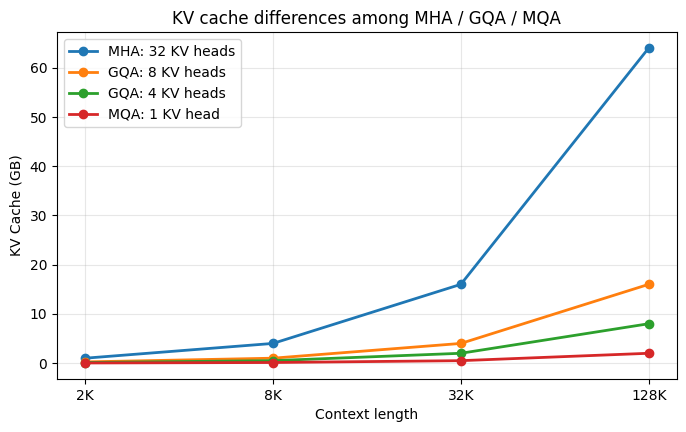

In [11]:
import matplotlib.pyplot as plt

num_layers = 32
num_query_heads = 32
head_dim = 128
seq_lengths = [2048, 8192, 32768, 131072]
seq_labels = ["2K", "8K", "32K", "128K"]
variants = {
    "MHA: 32 KV heads": 32,
    "GQA: 8 KV heads": 8,
    "GQA: 4 KV heads": 4,
    "MQA: 1 KV head": 1,
}

plt.figure(figsize=(8, 4.5))
for label, num_kv_heads in variants.items():
    sizes = [
        kv_cache_size(num_layers, num_kv_heads, head_dim, seq_len, 2) / 1024**3
        for seq_len in seq_lengths
    ]
    plt.plot(seq_labels, sizes, marker="o", linewidth=2, label=label)

plt.xlabel("Context length")
plt.ylabel("KV Cache (GB)")
plt.title("KV Cache differences across MHA / GQA / MQA")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Key observation: the longer the context, the more visible the memory savings from reducing KV heads.")
print("Note: MQA/GQA mainly save KV Cache and memory bandwidth during the decode phase.")


**So why not use MQA everywhere?**

Because saving memory is not free. Too few K/V heads means many Query heads are forced to look at the same set of data, and model expressiveness may degrade. MQA saves the most but sometimes loses more quality; MHA is the most stable but has the largest cache; GQA is often the engineering compromise.

| Variant | How K/V is stored | Pros | Cons |
|:---|:---|:---|:---|
| MHA | one K/V set per Q head | Strong expressiveness, most intuitive concept | Largest KV Cache |
| MQA | one shared K/V set for all Q heads | Smallest KV Cache, less decode bandwidth | Possible quality loss |
| GQA | one K/V set per group of Q heads | Trade-off between memory and quality | Slightly more cache than MQA |

In one sentence: **MHA is "one K/V set per head", MQA is "one K/V set for all heads", GQA is "one K/V set per group of heads".**

## 5. Model Quantization: Storing Weights with Fewer Bits

During training, weights are typically stored in FP16 (16-bit floating point), so a 7B model takes about 14 GB. Quantization reduces weights from 16 bits to 4 or 8 bits, cutting memory usage in half or even to a quarter. Let's first understand how quantization works with concrete numbers.

In [12]:
import numpy as np

np.random.seed(42)
W = np.random.randn(4, 4).astype(np.float32)
print("Original weights (FP32):")
print(np.round(W, 3))

scale = np.max(np.abs(W)) / 127
W_int8 = np.round(W / scale).clip(-127, 127).astype(np.int8)
print(f"\nScale factor scale = max(|W|) / 127 = {np.max(np.abs(W)):.4f} / 127 = {scale:.6f}")
print(f"\nQuantized (INT8):")
print(W_int8)

W_dequant = W_int8.astype(np.float32) * scale
error = np.mean(np.abs(W - W_dequant))
print(f"\nDequantized:\n{np.round(W_dequant, 3)}")
print(f"\nMAE: {error:.5f}")
print(f"Storage: 4 bytes/param -> 1 byte/param, saving 75%")


Read the values printed above and connect them to the concept in this cell.[[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]
 [ 0.242 -1.913 -1.725 -0.562]]

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.[[  33   -9   43  101]
 [ -16  -16  105   51]
 [ -31   36  -31  -31]
 [  16 -127 -114  -37]]

Read the values printed above and connect them to the concept in this cell.[[ 0.497 -0.136  0.648  1.522]
 [-0.241 -0.241  1.582  0.768]
 [-0.467  0.542 -0.467 -0.467]
 [ 0.241 -1.913 -1.717 -0.557]]

MAE: 0.00268
Read the values printed above and connect them to the concept in this cell.

In [13]:
import numpy as np

np.random.seed(42)
W_large = np.random.randn(64, 64).astype(np.float32)

def quantize_uniform(W, n_bits):
    n_levels = 2 ** (n_bits - 1) - 1
    scale = np.max(np.abs(W)) / n_levels
    W_q = np.round(W / scale).clip(-n_levels, n_levels)
    return W_q * scale

print(f"{\'Bits\':>4}  {\'MAE\':>8}  {\'Cosine sim\':>12}  {\'Storage %\':>8}")
print("-" * 38)
for bits in [16, 8, 6, 4, 3, 2]:
    W_r = W_large.copy() if bits == 16 else quantize_uniform(W_large, bits)
    mae = np.mean(np.abs(W_large - W_r))
    cos_sim = np.dot(W_large.flatten(), W_r.flatten()) / (np.linalg.norm(W_large) * np.linalg.norm(W_r) + 1e-8)
    ratio = bits / 16 * 100
    print(f"{bits:>4}  {mae:>8.5f}  {cos_sim:>12.8f}  {ratio:>7.0f}%")

print("\n4-bit cosine similarity > 0.99 -- direction is essentially preserved. Storage saved 75%.")


Read the values printed above and connect them to the concept in this cell.--------------------------------------
  16   0.00000    1.00000000      100%
   8   0.00774    0.99995960       50%
   6   0.03225    0.99930775       38%
   4   0.13990    0.98720088       25%
   3   0.32984    0.93346815       19%
   2   0.75890    0.52141723       12%

Read the values printed above and connect them to the concept in this cell.

In [14]:
def model_size_gb(params_b, bits):
    return params_b * 1e9 * bits / 8 / 1e9

models_s = [("LLaMA-2 7B", 7), ("LLaMA-2 13B", 13), ("LLaMA-2 70B", 70), ("Qwen-2 72B", 72)]
formats = [("FP16", 16), ("INT8", 8), ("4-bit", 4), ("GGUF Q4_K_M", 4.5), ("GGUF Q2_K", 2.5)]

print(f"{\'Model\':<16} " + "".join(f"{fn:>16}" for fn, _ in formats))
print("-" * 96)
for mname, params in models_s:
    row = f"{mname:<16} "
    for fname, bits in formats:
        row += f"{model_size_gb(params, bits):>14.1f} GB"
    print(row)
print("\nGGUF Q4_K_M is about 28% of FP16, with acceptable quality loss.")


Model FP16 INT8 4-bit GGUF Q4_K_M GGUF Q2_K------------------------------------------------------------------------------------------------
LLaMA-2 7B                 14.0 GB           7.0 GB           3.5 GB           3.9 GB           2.2 GB
LLaMA-2 13B                26.0 GB          13.0 GB           6.5 GB           7.3 GB           4.1 GB
LLaMA-2 70B               140.0 GB          70.0 GB          35.0 GB          39.4 GB          21.9 GB
Qwen-2 72B                144.0 GB          72.0 GB          36.0 GB          40.5 GB          22.5 GB

Loss

## 6. GGUF Format Explained

GGUF (GPT-Generated Unified Format) is the model file format used by the llama.cpp ecosystem. It packages model weights, metadata, and vocabulary into a single file without needing separate configuration files.

A GGUF file consists of three parts:

```
+----------------------------+
| Header                     |
|   magic: "GGUF"            |
|   version: 3               |
|   tensor_count: N          |
|   metadata_kv_count: M     |
+----------------------------+
| Metadata                   |
|   general.architecture     |
|   llama.context_length     |
|   tokenizer.ggml.tokens    |
|   ...                      |
+----------------------------+
| Tensor Data                |
|   token_embd.weight        |
|   blk.0.attn_q.weight      |
|   blk.0.attn_k.weight      |
|   ... (repeated N layers)  |
|   output.weight            |
+----------------------------+
```

GGUF quantization type naming convention (taking Q4_K_M as an example):

- **Q4**: weights stored in 4 bits
- **K**: k-quant method, different layers use different precision
- **M**: Medium, a compromise between size and accuracy

| Name | Bits | 7B model size | Use case |
|:-----|:-----|:--------------|:---------|
| Q8_0 | 8 bit | ~7.2 GB | Highest accuracy |
| Q5_K_M | ~5 bit | ~4.8 GB | Balance of accuracy and speed |
| Q4_K_M | ~4.5 bit | ~4.1 GB | Best value, most commonly used |
| Q3_K_M | ~3.5 bit | ~3.3 GB | When memory is tight |
| Q2_K | ~2.5 bit | ~2.5 GB | Extreme memory saving, quality loss |

In [15]:
# Load a GGUF model with llama-cpp-python
try:
    from llama_cpp import Llama
    print("llama-cpp-python is installed")
    print("Version:", llama_cpp.__version__ if hasattr(llama_cpp, "__version__") else "unknown")
except ImportError:
    print("llama-cpp-python is not installed.")
    print("Installation:")
    print("  pip install llama-cpp-python")
    print("  macOS: CMAKE_ARGS='-DGGML_METAL=on' pip install llama-cpp-python")
    print("  CUDA:  CMAKE_ARGS='-DGGML_CUDA=on' pip install llama-cpp-python")

print()
print("Usage:")
print("  from llama_cpp import Llama")
print('  llm = Llama(model_path="model-q4_k_m.gguf", n_ctx=512)')
print("  response = llm(prompt, max_tokens=50)")
print()
print("Model download:")
print("  https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF")


llama-cpp-python Not installed.Read the values printed above and connect them to the concept in this cell.  pip install llama-cpp-python
  macOS: CMAKE_ARGS='-DGGML_METAL=on' pip install llama-cpp-python
  CUDA:  CMAKE_ARGS='-DGGML_CUDA=on' pip install llama-cpp-python

Read the values printed above and connect them to the concept in this cell.  from llama_cpp import Llama
  llm = Llama(model_path="model-q4_k_m.gguf", n_ctx=512)
  response = llm(prompt, max_tokens=50)

Read the values printed above and connect them to the concept in this cell.  https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF


In [16]:
import os
import glob

import time

def find_gguf_model():
    search_paths = [
        os.path.expanduser("~/.cache/huggingface/hub"),
        os.path.expanduser("~/models"),
        os.path.expanduser("~/Downloads"),
    ]
    for path in search_paths:
        if os.path.exists(path):
            for f in glob.glob(os.path.join(path, "**/*.gguf"), recursive=True):
                return f
    return None

model_path = find_gguf_model()

if model_path:
    from llama_cpp import Llama
    file_size = os.path.getsize(model_path) / 1024**3
    print(f"Loading: {os.path.basename(model_path)} ({file_size:.2f} GB)")

    llm = Llama(model_path=model_path, n_ctx=512, verbose=False)

    prompt = "The capital of France is"
    print(f"Prompt: {prompt}")

    start = time.perf_counter()
    response = llm(prompt, max_tokens=32, temperature=0.0)
    elapsed = time.perf_counter() - start

    text = response["choices"][0]["text"]
    n_tokens = response["usage"]["completion_tokens"]
    print(f"Output: {text}")
    print(f"Speed: {n_tokens/elapsed:.1f} tokens/s")
else:
    print("No GGUF model file found.")
    print("Download example:")
    print("  wget https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF/resolve/main/qwen2.5-0.5b-instruct-q4_k_m.gguf")
    print("  Then load with Llama(model_path=...)")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  wget https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF/resolve/main/qwen2.5-0.5b-instruct-q4_k_m.gguf
Read the values printed above and connect them to the concept in this cell.

## 7. PagedAttention (vLLM)

KV Cache is allocated as one contiguous block of memory. Each request has a different generation length, and contiguous allocation leads to significant memory fragmentation. vLLM's PagedAttention divides the KV Cache into fixed-size "pages" (blocks), managing them like operating system virtual memory.

```
Traditional (contiguous memory):
+---------------------------+
| Request A (500 tokens)    |
+---------------------------+
|      (wasted fragment)    |
+------------+
| Request B (100) |
+------------+

PagedAttention:
+--+--+--+--+--+--+--+--+
|A1|B1|A2|C1|B2|A3|C2|A4|  Fixed-size pages
+--+--+--+--+--+--+--+--+  Non-contiguous but no fragmentation
```

In [17]:
import random

def simulate_memory(requests, block_size=16, alignment=64):
    contiguous_wasted = sum(((r + alignment - 1) // alignment) * alignment - r for r in requests)
    paged_wasted = sum((block_size - (r % block_size)) % block_size for r in requests)
    return contiguous_wasted, paged_wasted

random.seed(42)
scenarios = {
    "Short (10-100)": [random.randint(10, 100) for _ in range(100)],
    "Mixed (10-500)": [random.randint(10, 500) for _ in range(100)],
    "Long (100-2000)": [random.randint(100, 2000) for _ in range(50)],
}

for name, reqs in scenarios.items():
    cw, pw = simulate_memory(reqs)
    total = sum(reqs)
    print(f"{name:<20} Total {total:>6} tokens  Contiguous waste {cw/total*100:>5.1f}%  Paged waste {pw/total*100:>5.1f}%")

print("\nPaged waste rate is typically 3-5%, while contiguous allocation wastes 13-20%.")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

## 8. FlashAttention

KV Cache solves the "compute less" problem, while FlashAttention solves the "compute faster" problem -- more precisely, it makes Attention friendlier to the GPU's memory hierarchy.

A GPU has two layers of storage whose capacity and speed differ by orders of magnitude:

```text
+---------------------------------------------+
|  HBM (device memory)        large, slow     |
|  e.g. A100 80GB, bandwidth ~2 TB/s          |
|  stores: model weights, KV Cache, activations|
|                                              |
|         ^ read / write v (move data back/forth)|
|                                              |
|  SRAM (on-chip cache)       small, 10x+ fast |
|  e.g. A100 192KB/block, bandwidth ~19 TB/s   |
|  stores: the small chunk of Q/K/V being computed|
+---------------------------------------------+
```

The bottleneck of standard Attention is not the multiply-add compute itself, but HBM read/write traffic. A naive implementation first writes the entire $N \times N$ attention score matrix to HBM, then reads it back for softmax, then writes it back for the weighted sum. When $N=8192$ this intermediate matrix is 16 GB, and the cost of repeatedly moving it far exceeds the actual compute.

FlashAttention's approach is tiling: split Q, K, V into small blocks that fit in SRAM, move only a small batch into SRAM at a time, compute the full attention for that block in SRAM, and write only the final output back to HBM. The intermediate attention score matrix is never materialized.

There is one technical challenge: the softmax denominator $\sum_j \exp(s_j)$ depends on the entire row of K. If K is processed in blocks, how do you compute a correct softmax without having seen the whole row? The answer is online softmax -- as you iterate over K blocks, you incrementally maintain the "running maximum seen so far" and the "running denominator sum so far", and correct at the end into a result that is mathematically identical to a full softmax. Intuitively, you do not need to finish reading the entire row before normalizing; a rolling statistic lets you push the normalization "online".

One thing to emphasize: FlashAttention is **exact**, not an approximation. It is mathematically equivalent to standard Attention -- it only reorganizes the computation into a hardware-friendly form. This differs from the sparse attention and linear attention mentioned later, which genuinely reduce $O(N^2)$ at the cost of accuracy or expressiveness. FlashAttention does not change the formula; it only changes the execution order.

The cost is that it depends heavily on hardware details: a correct implementation must handle SRAM size, warp scheduling, asynchronous data movement, and other low-level concerns. This section only covers the concept; a full from-scratch implementation is in Appendix G.

### Version evolution: v1, v2, v3

FlashAttention has gone through three major iterations since 2022, each targeting a different bottleneck of the previous version:

| Version | Year | Key improvement | Speedup source |
|:---|:---|:---|:---|
| v1 | 2022 (Dao) | tiling + online softmax, HBM reads/writes from $O(N^2)$ down to $O(N^2/M)$ | fewer memory transfers |
| v2 | 2023 (Dao) | loop reorder (iterate Q outside, K/V inside), 2-4x fewer non-matmul ops | higher matmul share |
| v3 | 2024 (NVIDIA) | async warp-specialization + TMA + FP8, Hopper-specific | 1.5-2x over v2 |

v1 addresses the biggest bandwidth waste: writing the intermediate attention matrix back to HBM. By tiling Q, K, V and doing the math in SRAM, the result is written only once.

v2 notices a detail: v1's loop had K/V outside and Q inside, which forces updating accumulators across all Q tiles on every outer iteration, generating lots of non-matmul work. v2 reverses the loop -- Q outside, K/V inside -- each Q tile emits output as soon as it is done, cutting non-matmul work 2-4x and raising matmul's share of total FLOPs from 25-50% to 70-85%. Since matmul units on a GPU are much faster than general ALUs, this delivers real speedup.

v3 is the NVIDIA team's optimization tailored to the Hopper architecture (H100/H200). It uses hardware features only Hopper has: TMA (Tensor Memory Accelerator, asynchronous tensor copy) and FP8 Tensor Cores. Warp specialization lets a producer warp asynchronously load the next batch of data while a consumer warp computes, hiding HBM latency. The cost is hardware exclusivity -- A100 cannot reap these gains.

In [18]:
def standard_attn_memory(batch, heads, seq, bytes=2):
    return batch * heads * seq * seq * bytes

def flash_attn_memory(batch, heads, seq, d_head, bytes=2):
    return batch * seq * heads * d_head * bytes

def fmt(b):
    return f"{b/1024**3:.1f} GB" if b >= 1024**3 else f"{b/1024**2:.0f} MB"

print(f"{\'Seq len\':>8}  {\'Standard Attn\':>15}  {\'FlashAttention\':>15}  {\'Saving\':>8}")
print("-" * 55)
for seq in [512, 1024, 2048, 4096, 8192, 16384]:
    std = standard_attn_memory(1, 32, seq)
    flash = flash_attn_memory(1, 32, seq, 128)
    saving = (1 - flash / std) * 100
    print(f"{seq:>8d}  {fmt(std):>15}  {fmt(flash):>15}  {saving:>7.1f}%")

print("\nAt 8192 tokens, standard needs 16 GB for intermediate matrices, Flash needs only 4 MB.")


Read the values printed above and connect them to the concept in this cell.-------------------------------------------------------
     512            16 MB             4 MB     75.0%
    1024            64 MB             8 MB     87.5%
    2048           256 MB            16 MB     93.8%
    4096           1.0 GB            32 MB     96.9%
    8192           4.0 GB            64 MB     98.4%
   16384          16.0 GB           128 MB     99.2%

Read the values printed above and connect them to the concept in this cell.

In [19]:
import torch
import torch.nn.functional as F
import math
import time

has_flash = hasattr(torch.nn.functional, "scaled_dot_product_attention")
print(f"SDPA supported: {has_flash}")

if has_flash:
    batch, heads, seq, dim = 2, 8, 512, 64
    q = torch.randn(batch, heads, seq, dim)
    k = torch.randn(batch, heads, seq, dim)
    v = torch.randn(batch, heads, seq, dim)

    start = time.perf_counter()
    for _ in range(100):
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(dim)
        out_std = F.softmax(scores, dim=-1) @ v
    t_std = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(100):
        out_flash = F.scaled_dot_product_attention(q, k, v)
    t_flash = time.perf_counter() - start

    diff = (out_std - out_flash).abs().max().item()
    print(f"Standard: {t_std*1000:.1f} ms, SDPA: {t_flash*1000:.1f} ms, Speedup: {t_std/t_flash:.1f}x")
    print(f"Max difference: {diff:.2e}")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**FlashAttention's place in MoE inference**

MoE (Mixture-of-Experts) models split the FFN into multiple experts and route tokens dynamically. The key distinction: MoE changes the FFN layer, while the attention layer remains dense -- all tokens walk through the same Q/K/V weights. That means FlashAttention is still fully applicable in MoE models, benefiting both the prefill and decode phases.

The side effect to watch for comes after expert routing: different tokens are routed to different experts, and each expert receives an uneven number of tokens. To compute in parallel on a GPU, tokens bound for the same expert are usually gathered together and batched through the FFN. If one expert gets only 3 tokens while another gets 50, padding to the longest length wastes compute. This waste happens in the FFN, not in attention -- the attention batch is always the full token sequence, with no padding problem.

So in MoE inference, attention's cost is basically the same as in a dense model; the real engineering difficulty is the load imbalance and communication overhead after expert routing. FlashAttention's role here is unchanged: make each attention layer faster and more memory-efficient, freeing up budget for the expert portion.

A full from-scratch FlashAttention implementation (including tiling and a step-by-step derivation and hand calculation of online softmax) is in Appendix G.

## 9. Two Phases of Inference: Prefill vs Decode

| | Prefill | Decode |
|------|-----------|-------|
| What it does | Process prompt all at once | Generate tokens one by one |
| Bottleneck | Computation | Memory bandwidth |
| Optimization | FlashAttention | KV Cache + PagedAttention |

Prefill (50 tokens): 252.23 ms
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

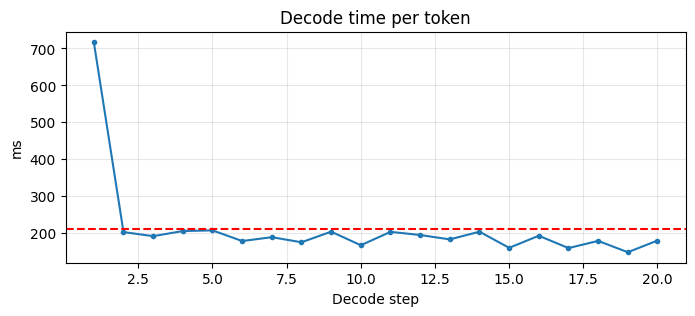

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

attn_demo = AttentionWithKVCache(d_model=256, num_heads=8)
prompt_len = 50
prompt = torch.randn(1, prompt_len, 256)

attn_demo.reset_cache()
start = time.perf_counter()
_ = attn_demo(prompt, use_cache=True)
t_prefill = time.perf_counter() - start
print(f"Prefill ({prompt_len} tokens): {t_prefill*1000:.2f} ms")

decode_times = []
for _ in range(20):
    new_tok = torch.randn(1, 1, 256)
    start = time.perf_counter()
    _ = attn_demo(new_tok, use_cache=True)
    decode_times.append((time.perf_counter() - start) * 1000)

avg_d = np.mean(decode_times)
print(f"Decode average: {avg_d:.2f} ms/token")

plt.figure(figsize=(8, 3))
plt.plot(range(1, 21), decode_times, marker=".")
plt.axhline(avg_d, color="red", linestyle="--")
plt.xlabel("Decode step")
plt.ylabel("ms")
plt.title("Per-token generation time during decode")
plt.grid(True, alpha=0.3)
plt.show()
print("Prefill is one-shot (parallel), Decode is sequential (token by token).")


## 10. Continuous Batching

Traditional batching waits for the entire batch to complete before processing the next one. Continuous Batching lets completed requests release immediately and new requests fill in right away.

```
Traditional:  Request A [========]  Request B [===]  idle wait...  Request C [waiting...]
Continuous:   Request A [========]  Request B [===]  Request C [====...]
                                                 ^ C starts immediately after B finishes
```

vLLM, TensorRT-LLM, and TGI all use Continuous Batching.

In [21]:
import random

def simulate_batching(num_requests=20, max_batch=4):
    random.seed(42)
    lengths = [max(5, int(random.gauss(50, 20))) for _ in range(num_requests)]
    t_trad = sum(max(lengths[i:i+max_batch]) for i in range(0, num_requests, max_batch))

    active = lengths[:max_batch]
    remaining = lengths[max_batch:]
    t_cont = 0
    while active:
        t_cont += 1
        new_active = []
        for l in active:
            if l > 1:
                new_active.append(l - 1)
            elif remaining:
                new_active.append(remaining.pop(0))
        active = new_active
    return t_trad, t_cont

print(f"{\'max_batch\':>10} {\'Traditional\':>12} {\'Continuous\':>12} {\'Speedup\':>8}")
print("-" * 46)
for mb in [2, 4, 8, 16]:
    t1, t2 = simulate_batching(max_batch=mb)
    print(f"{mb:>10} {t1:>12} {t2:>12} {t1/t2:>7.1f}x")


Read the values printed above and connect them to the concept in this cell.----------------------------------------
         2      563          516   1.1x
         4      332          268   1.2x
         8      213          167   1.3x
        16      149          105   1.4x


## 11. Summary of Acceleration Techniques

| Technique | What it does | Speedup/Savings | Accuracy loss |
|------|--------|---------|---------|
| KV Cache | Cache computed K, V | Compute 10-50x | None |
| KV Cache Quantization | Store K, V in INT8/INT4 | Memory 2-4x | Slight |
| MQA/GQA | Reduce the number of K/V heads | KV Cache 4-32x | Slight to moderate |
| FlashAttention | Compute attention in SRAM | Speed 2-4x, Memory 10-20x | None |
| Model Quantization | Store weights with fewer bits | Memory 2-4x | Slight |
| PagedAttention | Manage KV Cache with paging | Utilization 100% | None |
| Continuous Batching | Dynamic scheduling | Throughput 5-10x | None |
| GGUF | Unified packaging format | CPU/edge deployment | Depends on quantization |

Speculative decoding is covered in the next notebook.

## Summary

- Naive autoregressive generation repeatedly processes the historical prefix, so repeated prefix work grows roughly as O(N^2) with generation length
- KV Cache stores previously computed K and V, avoiding recomputation of prior tokens' K/V and hidden states
- KV Cache still consumes memory and is read during decode -- long sequences + large models create memory-capacity and bandwidth pressure
- MQA/GQA reduce the number of K/V heads, directly shrinking KV Cache
- Model quantization compresses FP16 to INT8/INT4, halving to quartering the size
- GGUF is the standard format for llama.cpp, loadable directly with llama-cpp-python
- FlashAttention computes in SRAM, intermediate results never written back to GPU memory, mathematically equivalent
- PagedAttention manages KV Cache with paging, eliminating fragmentation
- Prefill (compute-bound) vs Decode (often bandwidth-bound)
- Continuous Batching improves throughput 5-10x

Next section: Speculative decoding -- a small model guesses, a large model verifies.

## Exercises

> You can ask an AI to explain concepts, but please run the code and fill in the answers yourself.

**Exercise 1: KV Cache Memory Calculation**

A model has 32 layers, 32 heads, and 128 dimensions per head. Using FP16 storage, generating 4096 tokens. How much memory does the KV Cache for a single request occupy (in MB)?

Hint: `2 x layers x heads x head_dim x seq_len x 2`

In [22]:
num_layers = 32
num_heads = 32
head_dim = 128
seq_len = 4096

kv_bytes = 2 * num_layers * num_heads * head_dim * seq_len * 2
kv_mb = kv_bytes / (1024 * 1024)
print(f"KV Cache: {kv_mb:.0f} MB")
assert abs(kv_mb - 2048) < 10
print("✅ Exercise 1 passed")


KV Cache: 2048 MB
Exercise passed: you have understood this step.

**Exercise 2: Quantized Model Size**

A 13B parameter model is quantized from FP16 to 4-bit. How many GB does it shrink to?

Hint: FP16 uses 2 bytes per parameter, 4-bit uses 0.5 bytes per parameter.

In [23]:
params = 13e9
size_fp16 = params * 2 / 1e9
size_4bit = params * 0.5 / 1e9
print(f"FP16: {size_fp16:.1f} GB -> 4-bit: {size_4bit:.1f} GB")
assert abs(size_4bit - 6.5) < 0.5
print("✅ Exercise 2 passed")


FP16: 26.0 GB → 4-bit: 6.5 GB
Exercise passed: you have understood this step.

**Exercise 3: FlashAttention Memory Savings**

batch=1, heads=32, seq=8192, FP16. How much memory does the attention matrix occupy (in GB)?

Hint: number of elements x 2 bytes -> GB.

In [24]:
batch, heads, seq = 1, 32, 8192
attn_bytes = batch * heads * seq * seq * 2
attn_gb = attn_bytes / 1024**3
print(f"Attention matrix: {attn_gb:.1f} GB")
assert abs(attn_gb - 16.0) < 1.0
print("✅ Exercise 3 passed")


Read the values printed above and connect them to the concept in this cell.Exercise passed: you have understood this step.

## References

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017
- Shazeer, [Fast Transformer Decoding: One Write-Head is All You Need](https://arxiv.org/abs/1911.02150), 2019
- Ainslie et al., [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245), 2023
- Dao et al., [FlashAttention](https://arxiv.org/abs/2205.14135), 2022
- Dao, [FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning](https://arxiv.org/abs/2307.08691), 2023
- Shah et al., [FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision](https://arxiv.org/abs/2407.08608), 2024
- Kwon et al., [PagedAttention (vLLM)](https://arxiv.org/abs/2309.06180), 2023
- Frantar et al., [GPTQ](https://arxiv.org/abs/2210.17323), 2022
- Lin et al., [AWQ](https://arxiv.org/abs/2306.00978), 2023
- [GGUF Specification](https://github.com/ggerganov/ggml/blob/master/docs/gguf.md)
- [llama.cpp](https://github.com/ggerganov/llama.cpp)
- [vLLM](https://github.com/vllm-project/vllm)
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)